In [ ]:
In diesem Notebook wird die Research Question 2 Analysiert

2. Gibt es Unterschiede im Trinkgeldverhalten je nach Tageszeit und Wochentag?
Analysiert werden:
- durchschnittlicher Trinkgeldbetrag
- durchschnittlicher Trinkgeldanteil
- Unterschiede nach Uhrzeit
- Unterschiede nach Wochentag
- Unterschiede zwischen Werktag und Wochenende

Für diese Analyse werden nur Fahrten mit elektronischer Zahlung betrachtet, da Bar-Trinkgelder im Datensatz nicht zuverlässig enthalten sind.


In [1]:
# SparkSession starten und benötigte Libraries importieren

from pyspark.sql import SparkSession
from pyspark.sql import functions as F
import os
import matplotlib.pyplot as plt

spark = SparkSession.builder \
    .appName("RQ2 Tip Behavior by Time") \
    .getOrCreate()

spark

26/05/22 10:38:06 WARN Utils: Your hostname, bdlc-021 resolves to a loopback address: 127.0.1.1; using 10.176.129.84 instead (on interface ens3)
26/05/22 10:38:06 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/05/22 10:38:06 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


In [4]:
# USE_SAMPLE = True  -> Analyse mit kleinem Parquet-Sample
# USE_SAMPLE = False -> Analyse mit vollständigem Clean-Datensatz aus HDFS

USE_SAMPLE = True

RQ_NAME = "rq2_tip_behavior_by_time"

if USE_SAMPLE:
    DATA_PATH = "file:///home/cluster/BDLC/data_sample/yellow_taxi_clean_sample_84000_parquet"
    RESULT_PATH = f"/home/cluster/BDLC/results/prototype/{RQ_NAME}"
else:
    DATA_PATH = "/taxi/clean"
    RESULT_PATH = f"/home/cluster/BDLC/results/final/{RQ_NAME}"

# Result-Ordner erstellen, falls er noch nicht existiert
os.makedirs(RESULT_PATH, exist_ok=True)

print("Using sample:", USE_SAMPLE)
print("Data path:", DATA_PATH)
print("Result path:", RESULT_PATH)

Using sample: True
Data path: file:///home/cluster/BDLC/data_sample/yellow_taxi_clean_sample_84000_parquet
Result path: /home/cluster/BDLC/results/prototype/rq2_tip_behavior_by_time


In [5]:
# Clean-Datensatz laden.
# Beim Sample wird das lokale Parquet-Sample gelesen.
# Beim vollständigen Datensatz wird /taxi/clean aus HDFS gelesen.

df = spark.read.parquet(DATA_PATH)

df.printSchema()
print("Number of records:", df.count())

root
 |-- pickup_datetime: timestamp (nullable = true)
 |-- dropoff_datetime: timestamp (nullable = true)
 |-- passenger_count: double (nullable = true)
 |-- trip_distance_miles: double (nullable = true)
 |-- pickup_location_id: long (nullable = true)
 |-- dropoff_location_id: long (nullable = true)
 |-- payment_type: long (nullable = true)
 |-- fare_amount: double (nullable = true)
 |-- tip_amount: double (nullable = true)
 |-- total_amount: double (nullable = true)
 |-- pickup_year: integer (nullable = true)
 |-- pickup_month: integer (nullable = true)
 |-- pickup_hour: integer (nullable = true)
 |-- pickup_weekday: integer (nullable = true)
 |-- trip_duration_minutes: double (nullable = true)
 |-- trip_distance_km: double (nullable = true)
 |-- avg_speed_kmh: double (nullable = true)
 |-- tip_percentage: double (nullable = true)
 |-- file_year: integer (nullable = true)
 |-- file_month: integer (nullable = true)



[Stage 1:>                                                          (0 + 1) / 1]

Number of records: 84000


In [6]:
# Für die Trinkgeldanalyse werden nur elektronische Zahlungen verwendet.
# payment_type = 1 steht für Kreditkarte / elektronische Zahlung.
# Bar-Trinkgelder sind im Datensatz oft nicht zuverlässig erfasst.

df_tips = df.filter(F.col("payment_type") == 1)

print("Number of electronic payment records:", df_tips.count())

Number of electronic payment records: 58103


In [7]:
# Zusätzlich zum absoluten Trinkgeldbetrag berechnen wir einen Trinkgeldanteil.
# total_amount enthält bereits das Trinkgeld.
# Deshalb berechnen wir zusätzlich den Betrag vor Trinkgeld:
# amount_before_tip = total_amount - tip_amount
#
# tip_rate_percent = tip_amount / amount_before_tip * 100
#
# Dadurch wird das Trinkgeld im Verhältnis zum Betrag vor Trinkgeld betrachtet.

df_tips = df_tips.withColumn(
    "amount_before_tip",
    F.col("total_amount") - F.col("tip_amount")
).withColumn(
    "tip_rate_percent",
    F.when(
        F.col("amount_before_tip") > 0,
        F.col("tip_amount") / F.col("amount_before_tip") * 100
    ).otherwise(None)
)

df_tips.select(
    "pickup_datetime",
    "pickup_hour",
    "pickup_weekday",
    "tip_amount",
    "total_amount",
    "amount_before_tip",
    "tip_rate_percent"
).show(10, truncate=False)

+-------------------+-----------+--------------+----------+------------+------------------+-------------------+
|pickup_datetime    |pickup_hour|pickup_weekday|tip_amount|total_amount|amount_before_tip |tip_rate_percent   |
+-------------------+-----------+--------------+----------+------------+------------------+-------------------+
|2015-01-23 20:03:32|20         |6             |3.4       |21.2        |17.8              |19.101123595505616 |
|2015-01-09 23:53:12|23         |6             |0.03      |6.33        |6.3               |0.47619047619047616|
|2015-01-10 18:54:13|18         |7             |1.62      |8.92        |7.3               |22.19178082191781  |
|2015-01-22 20:27:07|20         |5             |1.76      |10.56       |8.8               |20.0               |
|2015-01-31 08:51:17|8          |7             |2.9       |12.7        |9.799999999999999 |29.591836734693878 |
|2015-01-25 11:49:08|11         |1             |1.55      |9.35        |7.8               |19.8717948717

In [8]:
# Erste Übersicht über Trinkgeldbetrag und Trinkgeldanteil.
# Damit prüfen wir, ob die Werte plausibel aussehen.

df_tips.select(
    "tip_amount",
    "total_amount",
    "amount_before_tip",
    "tip_rate_percent"
).describe().show()

26/05/22 10:39:35 WARN SparkStringUtils: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.


+-------+------------------+------------------+------------------+------------------+
|summary|        tip_amount|      total_amount| amount_before_tip|  tip_rate_percent|
+-------+------------------+------------------+------------------+------------------+
|  count|             58103|             58103|             58103|             58103|
|   mean|2.7979784176376454|18.228420391378883|15.430441973749323|18.662001774406804|
| stddev|2.5574703691499665|13.717138243378603|11.700512087506082|14.489072128073841|
|    min|               0.0|               3.8|               3.3|               0.0|
|    max|              88.0|             259.8|             259.8| 2315.789473684212|
+-------+------------------+------------------+------------------+------------------+



In [9]:
# Obwohl die Daten bereits bereinigt sind, entfernen wir für diese Analyse noch Fälle,
# bei denen der berechnete Trinkgeldanteil NULL oder extrem hoch ist.
# Sehr hohe Trinkgeldanteile können einzelne Sonderfälle oder Datenfehler sein.
#
# Grenzwert: max. 100% Trinkgeldanteil.
# Das ist grosszügig, entfernt aber extreme Ausreisser.

df_tips_clean = df_tips \
    .filter(F.col("tip_rate_percent").isNotNull()) \
    .filter(~F.isnan(F.col("tip_rate_percent"))) \
    .filter(F.col("tip_rate_percent") >= 0) \
    .filter(F.col("tip_rate_percent") <= 100)

print("Records after tip-rate filtering:", df_tips_clean.count())

Records after tip-rate filtering: 58060


In [10]:
# Spark dayofweek:
# 1 = Sunday
# 2 = Monday
# 3 = Tuesday
# 4 = Wednesday
# 5 = Thursday
# 6 = Friday
# 7 = Saturday
#
# Für die Darstellung soll die Woche mit Monday beginnen.
# Deshalb erstellen wir zusätzlich weekday_order:
# Monday = 1, ..., Sunday = 7

df_tips_clean = df_tips_clean.withColumn(
    "weekday_name",
    F.when(F.col("pickup_weekday") == 1, "Sunday")
     .when(F.col("pickup_weekday") == 2, "Monday")
     .when(F.col("pickup_weekday") == 3, "Tuesday")
     .when(F.col("pickup_weekday") == 4, "Wednesday")
     .when(F.col("pickup_weekday") == 5, "Thursday")
     .when(F.col("pickup_weekday") == 6, "Friday")
     .when(F.col("pickup_weekday") == 7, "Saturday")
).withColumn(
    "weekday_order",
    F.when(F.col("pickup_weekday") == 2, 1)  # Monday
     .when(F.col("pickup_weekday") == 3, 2)  # Tuesday
     .when(F.col("pickup_weekday") == 4, 3)  # Wednesday
     .when(F.col("pickup_weekday") == 5, 4)  # Thursday
     .when(F.col("pickup_weekday") == 6, 5)  # Friday
     .when(F.col("pickup_weekday") == 7, 6)  # Saturday
     .when(F.col("pickup_weekday") == 1, 7)  # Sunday
)

In [ ]:
Analyse 1: Trinkgeld nach Uhrzeit

In [11]:
# Trinkgeldverhalten pro Stunde berechnen.
# Wir verwenden:
# - Anzahl Fahrten
# - durchschnittlicher Trinkgeldbetrag
# - durchschnittlicher Trinkgeldanteil
# - Median des Trinkgeldanteils als robustere Kennzahl

tips_by_hour = df_tips_clean.groupBy("pickup_hour") \
    .agg(
        F.count("*").alias("number_of_trips"),
        F.round(F.avg("tip_amount"), 2).alias("avg_tip_amount"),
        F.round(F.avg("tip_rate_percent"), 2).alias("avg_tip_rate_percent"),
        F.round(F.expr("percentile_approx(tip_rate_percent, 0.5)"), 2).alias("median_tip_rate_percent")
    ) \
    .orderBy("pickup_hour")

tips_by_hour.show(24)

[Stage 14:>                                                         (0 + 1) / 1]

+-----------+---------------+--------------+--------------------+-----------------------+
|pickup_hour|number_of_trips|avg_tip_amount|avg_tip_rate_percent|median_tip_rate_percent|
+-----------+---------------+--------------+--------------------+-----------------------+
|          0|           1760|          2.92|               18.11|                  19.99|
|          1|           1215|          2.62|               18.27|                   20.0|
|          2|            770|          2.43|               18.05|                  19.97|
|          3|            565|          2.61|               17.79|                  19.95|
|          4|            349|          2.97|               17.27|                  19.94|
|          5|            498|          3.46|               17.19|                  19.93|
|          6|           1204|          2.71|               17.35|                  19.92|
|          7|           2198|          2.52|                18.2|                  19.95|
|         

In [12]:
# Aggregierte Tabelle als CSV speichern.

tips_by_hour_pd = tips_by_hour.toPandas()

tips_by_hour_pd.to_csv(
    f"{RESULT_PATH}/tips_by_hour.csv",
    index=False
)

tips_by_hour_pd

,pickup_hour,number_of_trips,avg_tip_amount,avg_tip_rate_percent,median_tip_rate_percent
0,0,1760,2.92,18.11,19.99
1,1,1215,2.62,18.27,20.00
2,2,770,2.43,18.05,19.97
3,3,565,2.61,17.79,19.95
4,4,349,2.97,17.27,19.94
5,5,498,3.46,17.19,19.93
6,6,1204,2.71,17.35,19.92
7,7,2198,2.52,18.20,19.95
8,8,2824,2.61,18.37,20.00
9,9,2763,2.59,18.44,20.00


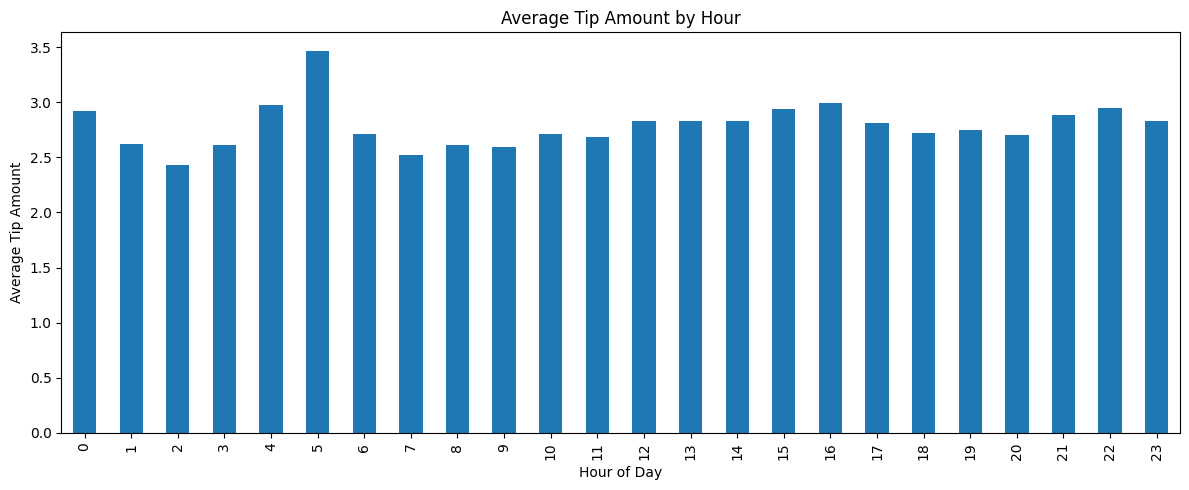

In [13]:
# Balkendiagramm: durchschnittlicher Trinkgeldbetrag pro Stunde.

ax = tips_by_hour_pd.plot(
    x="pickup_hour",
    y="avg_tip_amount",
    kind="bar",
    figsize=(12, 5),
    legend=False,
    title="Average Tip Amount by Hour"
)

ax.set_xlabel("Hour of Day")
ax.set_ylabel("Average Tip Amount")

plt.tight_layout()
plt.savefig(f"{RESULT_PATH}/avg_tip_amount_by_hour.png", dpi=150)
plt.show()

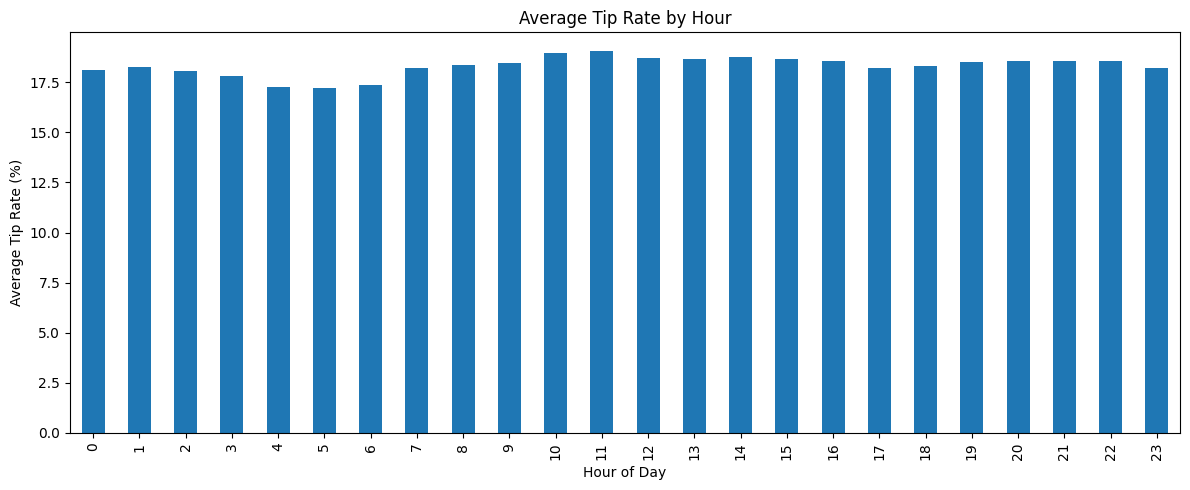

In [14]:
# Balkendiagramm: durchschnittlicher Trinkgeldanteil pro Stunde.
# Diese Kennzahl ist besser vergleichbar als der reine Trinkgeldbetrag.

ax = tips_by_hour_pd.plot(
    x="pickup_hour",
    y="avg_tip_rate_percent",
    kind="bar",
    figsize=(12, 5),
    legend=False,
    title="Average Tip Rate by Hour"
)

ax.set_xlabel("Hour of Day")
ax.set_ylabel("Average Tip Rate (%)")

plt.tight_layout()
plt.savefig(f"{RESULT_PATH}/avg_tip_rate_by_hour.png", dpi=150)
plt.show()

In [15]:
# Stunde mit dem höchsten durchschnittlichen Trinkgeldanteil bestimmen.

tips_by_hour.orderBy(F.desc("avg_tip_rate_percent")).limit(5).show()

+-----------+---------------+--------------+--------------------+-----------------------+
|pickup_hour|number_of_trips|avg_tip_amount|avg_tip_rate_percent|median_tip_rate_percent|
+-----------+---------------+--------------+--------------------+-----------------------+
|         11|           2859|          2.68|               19.04|                   20.0|
|         10|           2614|          2.71|               18.98|                   20.0|
|         14|           3253|          2.83|               18.78|                   20.0|
|         12|           2971|          2.83|                18.7|                   20.0|
|         13|           3054|          2.83|               18.68|                   20.0|
+-----------+---------------+--------------+--------------------+-----------------------+



In [ ]:
Analyse 2: Trinkgeld nach Wochentag

In [16]:
# Trinkgeldverhalten pro Wochentag berechnen.
# Sortiert wird mit weekday_order, damit Monday zuerst kommt.

tips_by_weekday = df_tips_clean.groupBy(
    "weekday_order",
    "weekday_name"
).agg(
    F.count("*").alias("number_of_trips"),
    F.round(F.avg("tip_amount"), 2).alias("avg_tip_amount"),
    F.round(F.avg("tip_rate_percent"), 2).alias("avg_tip_rate_percent"),
    F.round(F.expr("percentile_approx(tip_rate_percent, 0.5)"), 2).alias("median_tip_rate_percent")
).orderBy("weekday_order")

tips_by_weekday.show()

+-------------+------------+---------------+--------------+--------------------+-----------------------+
|weekday_order|weekday_name|number_of_trips|avg_tip_amount|avg_tip_rate_percent|median_tip_rate_percent|
+-------------+------------+---------------+--------------+--------------------+-----------------------+
|            1|      Monday|           7504|          2.86|               18.52|                   20.0|
|            2|     Tuesday|           8432|          2.73|               18.57|                   20.0|
|            3|   Wednesday|           8952|          2.84|               18.56|                   20.0|
|            4|    Thursday|           9167|          2.87|               18.49|                   20.0|
|            5|      Friday|           8888|          2.77|                18.3|                   20.0|
|            6|    Saturday|           8139|          2.61|               18.49|                   20.0|
|            7|      Sunday|           6978|          2

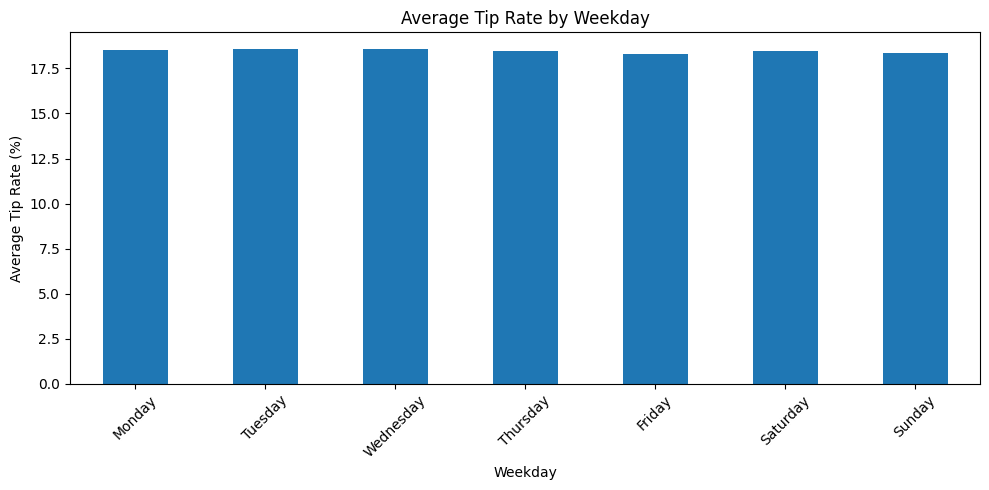

In [17]:
# Tabelle speichern und durchschnittlichen Trinkgeldanteil pro Wochentag visualisieren.
# Die Reihenfolge ist bereits durch weekday_order korrekt vorbereitet.

tips_by_weekday_pd = tips_by_weekday.toPandas()

tips_by_weekday_pd.to_csv(
    f"{RESULT_PATH}/tips_by_weekday.csv",
    index=False
)

ax = tips_by_weekday_pd.plot(
    x="weekday_name",
    y="avg_tip_rate_percent",
    kind="bar",
    figsize=(10, 5),
    legend=False,
    title="Average Tip Rate by Weekday"
)

ax.set_xlabel("Weekday")
ax.set_ylabel("Average Tip Rate (%)")

plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(f"{RESULT_PATH}/avg_tip_rate_by_weekday.png", dpi=150)
plt.show()

In [ ]:
Analyse 3: Werktag vs Wochenende

In [18]:
# Neue Kategorie erstellen:
# Weekend = Samstag oder Sonntag
# Weekday = Montag bis Freitag

df_tips_day_type = df_tips_clean.withColumn(
    "day_type",
    F.when(F.col("pickup_weekday").isin(1, 7), "Weekend")
     .otherwise("Weekday")
)

In [19]:
# Trinkgeldverhalten zwischen Werktag und Wochenende vergleichen.

tips_by_day_type = df_tips_day_type.groupBy("day_type") \
    .agg(
        F.count("*").alias("number_of_trips"),
        F.round(F.avg("tip_amount"), 2).alias("avg_tip_amount"),
        F.round(F.avg("tip_rate_percent"), 2).alias("avg_tip_rate_percent"),
        F.round(F.expr("percentile_approx(tip_rate_percent, 0.5)"), 2).alias("median_tip_rate_percent")
    ) \
    .orderBy("day_type")

tips_by_day_type.show()

[Stage 39:>                                                         (0 + 1) / 1]

+--------+---------------+--------------+--------------------+-----------------------+
|day_type|number_of_trips|avg_tip_amount|avg_tip_rate_percent|median_tip_rate_percent|
+--------+---------------+--------------+--------------------+-----------------------+
| Weekday|          42943|          2.81|               18.49|                   20.0|
| Weekend|          15117|           2.7|               18.43|                   20.0|
+--------+---------------+--------------+--------------------+-----------------------+



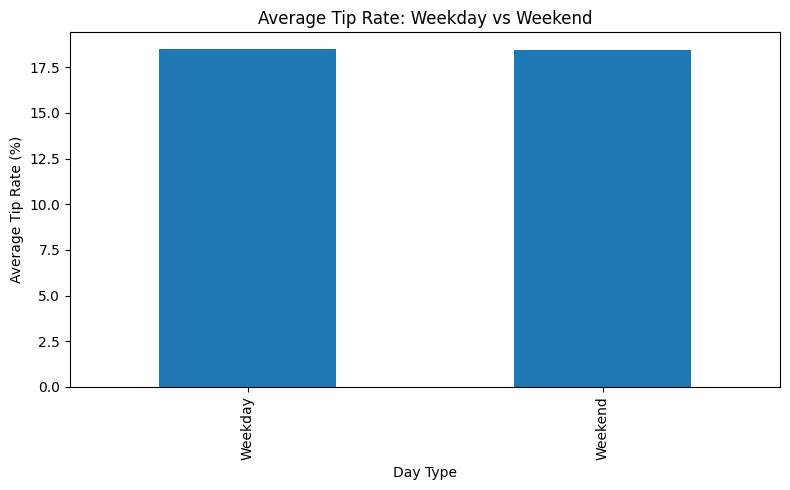

In [20]:
# Tabelle speichern und Vergleich visualisieren.

tips_by_day_type_pd = tips_by_day_type.toPandas()

tips_by_day_type_pd.to_csv(
    f"{RESULT_PATH}/tips_by_day_type.csv",
    index=False
)

ax = tips_by_day_type_pd.plot(
    x="day_type",
    y="avg_tip_rate_percent",
    kind="bar",
    figsize=(8, 5),
    legend=False,
    title="Average Tip Rate: Weekday vs Weekend"
)

ax.set_xlabel("Day Type")
ax.set_ylabel("Average Tip Rate (%)")

plt.tight_layout()
plt.savefig(f"{RESULT_PATH}/avg_tip_rate_weekday_vs_weekend.png", dpi=150)
plt.show()

In [ ]:
Analyse 4: Heatmap Wochentag × Uhrzeit

In [21]:
# Trinkgeldanteil nach Wochentag und Stunde berechnen.
# Diese Heatmap zeigt, ob es bestimmte Zeitfenster mit höherem Trinkgeldanteil gibt.
# Sortiert wird mit weekday_order, damit Monday zuerst kommt.

tips_weekday_hour = df_tips_clean.groupBy(
    "weekday_order",
    "weekday_name",
    "pickup_hour"
).agg(
    F.count("*").alias("number_of_trips"),
    F.round(F.avg("tip_rate_percent"), 2).alias("avg_tip_rate_percent")
).orderBy(
    "weekday_order",
    "pickup_hour"
)

tips_weekday_hour.show(200)

+-------------+------------+-----------+---------------+--------------------+
|weekday_order|weekday_name|pickup_hour|number_of_trips|avg_tip_rate_percent|
+-------------+------------+-----------+---------------+--------------------+
|            1|      Monday|          0|            109|               17.87|
|            1|      Monday|          1|             72|               18.69|
|            1|      Monday|          2|             49|               17.71|
|            1|      Monday|          3|             29|               14.03|
|            1|      Monday|          4|             28|               19.32|
|            1|      Monday|          5|             81|               17.37|
|            1|      Monday|          6|            196|               17.21|
|            1|      Monday|          7|            367|               18.58|
|            1|      Monday|          8|            467|               18.48|
|            1|      Monday|          9|            390|        

In [22]:
# Ergebnis als CSV speichern.

tips_weekday_hour_pd = tips_weekday_hour.toPandas()

tips_weekday_hour_pd.to_csv(
    f"{RESULT_PATH}/tips_weekday_hour.csv",
    index=False
)

tips_weekday_hour_pd.head()

,weekday_order,weekday_name,pickup_hour,number_of_trips,avg_tip_rate_percent
0,1,Monday,0,109,17.87
1,1,Monday,1,72,18.69
2,1,Monday,2,49,17.71
3,1,Monday,3,29,14.03
4,1,Monday,4,28,19.32


In [23]:
# Pivot-Tabelle erstellen:
# Zeilen = Wochentage
# Spalten = Stunden
# Werte = durchschnittlicher Trinkgeldanteil
#
# Die Reihenfolge wird manuell auf Monday bis Sunday gesetzt.

heatmap_tip_weekday_hour = tips_weekday_hour_pd.pivot(
    index="weekday_name",
    columns="pickup_hour",
    values="avg_tip_rate_percent"
)

weekday_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
]

heatmap_tip_weekday_hour = heatmap_tip_weekday_hour.reindex(weekday_order)

heatmap_tip_weekday_hour

pickup_hour,0,1,2,3,4,5,6,7,8,9,...,14,15,16,17,18,19,20,21,22,23
weekday_name,,,,,,,,,,,,,,,,,,,,,
Monday,17.87,18.69,17.71,14.03,19.32,17.37,17.21,18.58,18.48,18.55,...,19.32,18.46,17.75,18.28,18.24,18.74,18.68,18.69,18.40,18.68
Tuesday,18.12,19.49,14.47,18.03,19.20,17.72,18.19,17.99,18.09,18.50,...,18.89,18.85,18.37,18.10,18.16,18.46,18.38,19.02,19.23,18.21
Wednesday,18.40,19.86,17.85,16.79,14.76,17.31,17.42,18.50,17.88,18.53,...,19.08,18.88,18.16,18.36,18.05,18.72,18.68,18.66,19.03,18.81
Thursday,18.89,17.72,18.46,20.17,15.25,18.11,17.04,18.33,18.59,18.35,...,18.47,18.70,19.24,18.00,18.03,18.37,18.58,18.02,18.85,17.96
Friday,18.53,19.86,18.34,17.31,17.68,16.32,16.33,18.19,18.43,18.36,...,18.45,18.46,18.04,17.66,18.30,18.05,18.31,19.26,17.82,18.04
Saturday,17.76,17.69,18.34,18.67,17.12,15.69,16.93,16.96,19.06,18.70,...,18.19,18.48,19.49,18.64,18.98,18.80,18.91,18.22,18.40,18.11
Sunday,17.61,17.60,18.16,17.51,17.63,17.51,18.81,17.72,18.82,17.91,...,19.11,18.82,18.76,18.56,18.70,18.23,18.24,17.98,18.12,17.77


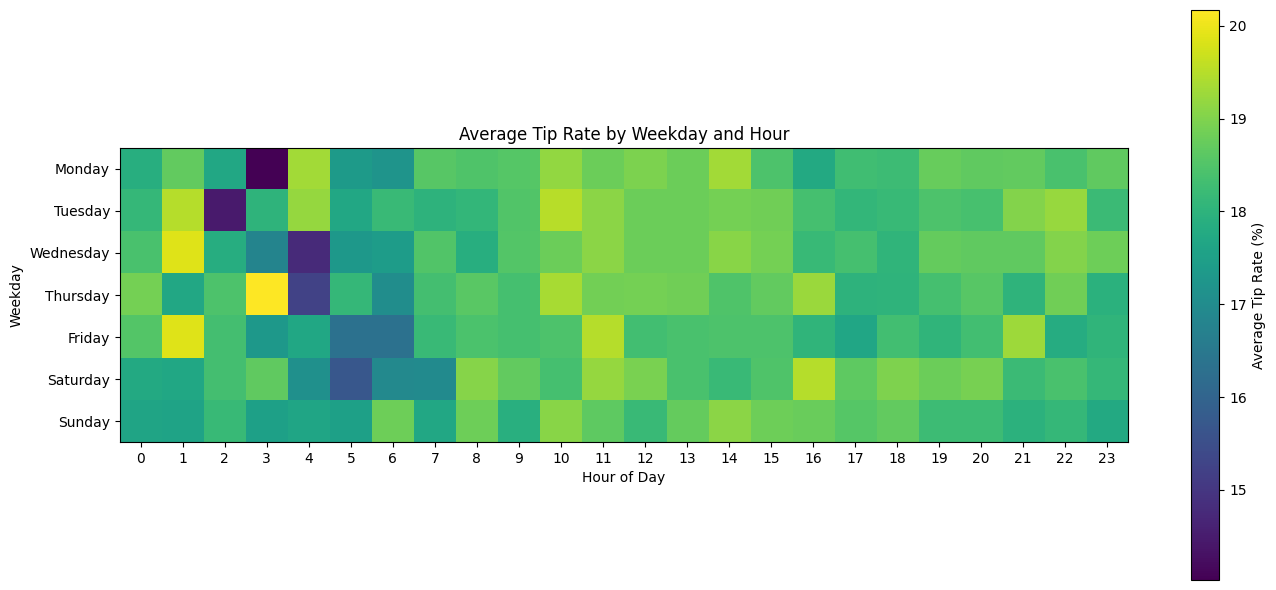

In [24]:
# Heatmap für Trinkgeldanteil nach Wochentag und Uhrzeit.

fig, ax = plt.subplots(figsize=(14, 6))

image = ax.imshow(heatmap_tip_weekday_hour)

ax.set_xticks(range(len(heatmap_tip_weekday_hour.columns)))
ax.set_xticklabels(heatmap_tip_weekday_hour.columns)

ax.set_yticks(range(len(heatmap_tip_weekday_hour.index)))
ax.set_yticklabels(heatmap_tip_weekday_hour.index)

ax.set_xlabel("Hour of Day")
ax.set_ylabel("Weekday")
ax.set_title("Average Tip Rate by Weekday and Hour")

plt.colorbar(image, ax=ax, label="Average Tip Rate (%)")

plt.tight_layout()
plt.savefig(f"{RESULT_PATH}/heatmap_tip_rate_weekday_hour.png", dpi=150)
plt.show()

In [ ]:
Analyse 5: Heatmap Werktag/Wochenende × Uhrzeit

In [25]:
# Trinkgeldanteil nach Weekday/Weekend und Stunde berechnen.

tips_day_type_hour = df_tips_day_type.groupBy(
    "day_type",
    "pickup_hour"
).agg(
    F.count("*").alias("number_of_trips"),
    F.round(F.avg("tip_rate_percent"), 2).alias("avg_tip_rate_percent")
).orderBy(
    "day_type",
    "pickup_hour"
)

tips_day_type_hour.show(100)

+--------+-----------+---------------+--------------------+
|day_type|pickup_hour|number_of_trips|avg_tip_rate_percent|
+--------+-----------+---------------+--------------------+
| Weekday|          0|            969|               18.45|
| Weekday|          1|            503|               19.15|
| Weekday|          2|            300|               17.74|
| Weekday|          3|            181|               17.28|
| Weekday|          4|            156|               17.13|
| Weekday|          5|            384|               17.38|
| Weekday|          6|           1044|               17.28|
| Weekday|          7|           1963|               18.32|
| Weekday|          8|           2445|               18.28|
| Weekday|          9|           2249|               18.46|
| Weekday|         10|           2004|               19.07|
| Weekday|         11|           2104|               19.08|
| Weekday|         12|           2111|               18.74|
| Weekday|         13|           2218|  

In [26]:
# Tabelle speichern und Pivot-Tabelle für Heatmap erstellen.

tips_day_type_hour_pd = tips_day_type_hour.toPandas()

tips_day_type_hour_pd.to_csv(
    f"{RESULT_PATH}/tips_day_type_hour.csv",
    index=False
)

heatmap_tip_day_type_hour = tips_day_type_hour_pd.pivot(
    index="day_type",
    columns="pickup_hour",
    values="avg_tip_rate_percent"
)

heatmap_tip_day_type_hour = heatmap_tip_day_type_hour.reindex(["Weekday", "Weekend"])

heatmap_tip_day_type_hour

pickup_hour,0,1,2,3,4,5,6,7,8,9,...,14,15,16,17,18,19,20,21,22,23
day_type,,,,,,,,,,,,,,,,,,,,,
Weekday,18.45,19.15,17.74,17.28,17.13,17.38,17.28,18.32,18.28,18.46,...,18.83,18.67,18.33,18.07,18.15,18.46,18.52,18.71,18.67,18.29
Weekend,17.69,17.64,18.25,18.03,17.38,16.53,17.78,17.28,18.95,18.36,...,18.64,18.66,19.14,18.61,18.85,18.56,18.62,18.12,18.29,18.00


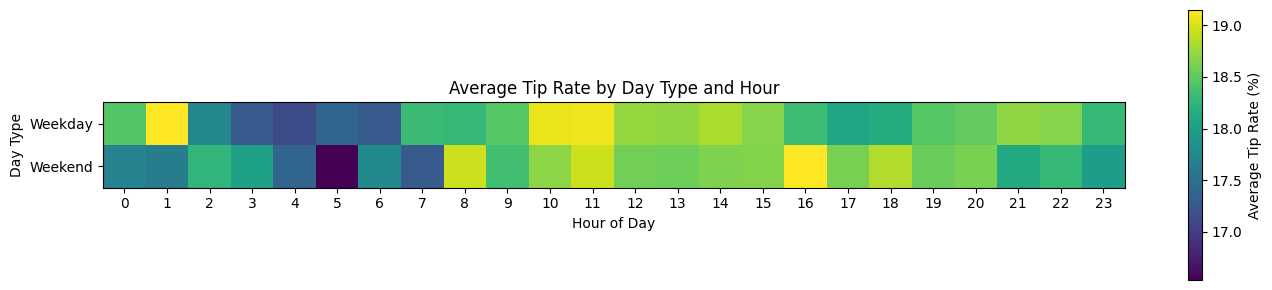

In [27]:
# Heatmap für Trinkgeldanteil nach Weekday/Weekend und Uhrzeit.

fig, ax = plt.subplots(figsize=(14, 3))

image = ax.imshow(heatmap_tip_day_type_hour)

ax.set_xticks(range(len(heatmap_tip_day_type_hour.columns)))
ax.set_xticklabels(heatmap_tip_day_type_hour.columns)

ax.set_yticks(range(len(heatmap_tip_day_type_hour.index)))
ax.set_yticklabels(heatmap_tip_day_type_hour.index)

ax.set_xlabel("Hour of Day")
ax.set_ylabel("Day Type")
ax.set_title("Average Tip Rate by Day Type and Hour")

plt.colorbar(image, ax=ax, label="Average Tip Rate (%)")

plt.tight_layout()
plt.savefig(f"{RESULT_PATH}/heatmap_tip_rate_day_type_hour.png", dpi=150)
plt.show()

In [ ]:
Analyse 5: Vor-Corona vs. Corona-Zeitraum

In [28]:
# Optionaler Vergleich:
# 2015-2019 = vor Corona
# 2020-2021 = Corona-Zeitraum

df_tips_period = df_tips_clean.withColumn(
    "period",
    F.when(F.col("file_year").between(2015, 2019), "2015-2019")
     .when(F.col("file_year").between(2020, 2021), "2020-2021")
)

In [29]:
# Trinkgeldanteil pro Stunde und Periode berechnen.

tips_by_hour_period = df_tips_period.groupBy(
    "period",
    "pickup_hour"
).agg(
    F.count("*").alias("number_of_trips"),
    F.round(F.avg("tip_rate_percent"), 2).alias("avg_tip_rate_percent")
).orderBy(
    "period",
    "pickup_hour"
)

tips_by_hour_period.show(100)

+---------+-----------+---------------+--------------------+
|   period|pickup_hour|number_of_trips|avg_tip_rate_percent|
+---------+-----------+---------------+--------------------+
|2015-2019|          0|           1463|               18.15|
|2015-2019|          1|           1025|                18.3|
|2015-2019|          2|            646|               18.34|
|2015-2019|          3|            493|                17.9|
|2015-2019|          4|            301|               17.03|
|2015-2019|          5|            393|               17.35|
|2015-2019|          6|            860|               17.23|
|2015-2019|          7|           1617|               18.13|
|2015-2019|          8|           2015|               18.26|
|2015-2019|          9|           1930|               18.32|
|2015-2019|         10|           1764|               18.82|
|2015-2019|         11|           1898|               19.02|
|2015-2019|         12|           1916|               18.53|
|2015-2019|         13| 

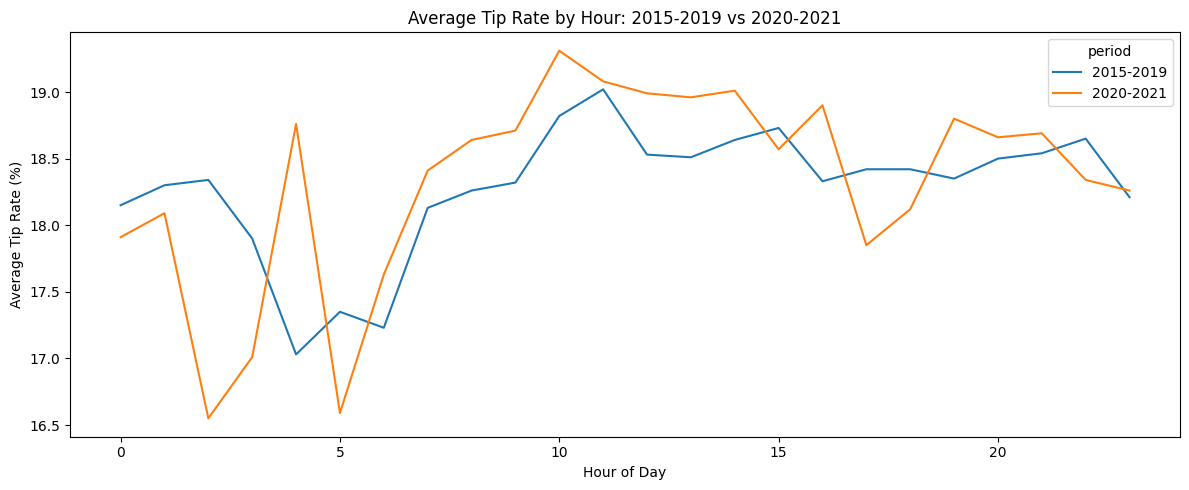

In [30]:
# Tabelle speichern und Liniendiagramm erstellen.

tips_by_hour_period_pd = tips_by_hour_period.toPandas()

tips_by_hour_period_pd.to_csv(
    f"{RESULT_PATH}/tips_by_hour_period.csv",
    index=False
)

period_tip_pivot = tips_by_hour_period_pd.pivot(
    index="pickup_hour",
    columns="period",
    values="avg_tip_rate_percent"
)

ax = period_tip_pivot.plot(
    kind="line",
    figsize=(12, 5),
    title="Average Tip Rate by Hour: 2015-2019 vs 2020-2021"
)

ax.set_xlabel("Hour of Day")
ax.set_ylabel("Average Tip Rate (%)")

plt.tight_layout()
plt.savefig(f"{RESULT_PATH}/avg_tip_rate_by_hour_period.png", dpi=150)
plt.show()

In [31]:
spark.stop()